# Liverpool Energy Performance Certificate Analysis
## COM6003 Data Science — Buckinghamshire New University 2025-26

**Dataset:** Energy Performance of Buildings — Liverpool (Local Authority: E08000012)  
**Source:** Ministry of Housing, Communities and Local Government (MHCLG) Open Data Portal  
**Assessment method:** Standard Assessment Procedure (SAP) and Reduced SAP (RdSAP)  

This notebook presents a complete end-to-end data science pipeline covering data acquisition, feature engineering, data wrangling, descriptive analytics, diagnostic analytics, predictive modelling, and recommendations for improving energy efficiency in Liverpool buildings.

## Section 1: Data Acquisition and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_theme(style='whitegrid', palette='muted')

# Consistent colour palettes used throughout
RATING_COLORS  = {'A': '#2ecc71', 'B': '#27ae60', 'C': '#f1c40f',
                   'D': '#e67e22', 'E': '#e74c3c'}
AGE_COLORS     = ['#8e44ad','#2980b9','#27ae60','#f39c12',
                   '#e67e22','#e74c3c','#1abc9c']
PALETTE        = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
EFF_COLORS     = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c']
AGE_ORDER      = ['Pre-1900','1900-1949','1950-1975','1976-1990',
                   '1991-2002','2003-2021','Post-2021']
EFF_ORDER      = ['Very Good','Good','Average','Poor','Very Poor']

# Helper: annotate bars with count and optional percentage
def bar_labels(ax, bars, values, total=None, fmt=',.0f',
               offset_pct=0.015, fontsize=9.5, color='black'):
    ylim = ax.get_ylim()
    span = ylim[1] - ylim[0]
    for bar, val in zip(bars, values):
        label = f'{val:{fmt}}'
        if total:
            label += f'\n({val / total * 100:.1f}%)'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + span * offset_pct,
                label, ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold', color=color)

# Helper: annotate horizontal bars
def hbar_labels(ax, bars, values, offset_pct=0.01, fontsize=9.5):
    xlim = ax.get_xlim()
    span = xlim[1] - xlim[0]
    for bar, val in zip(bars, values):
        ax.text(val + span * offset_pct,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center',
                fontsize=fontsize, fontweight='bold')

df   = pd.read_csv('certificates.csv', low_memory=False)
recs = pd.read_csv('recommendations.csv', low_memory=False)

print(f'Certificates  : {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Recommendations: {recs.shape[0]:,} rows, {recs.shape[1]} columns')
print(f'Local authority: {df["LOCAL_AUTHORITY_LABEL"].unique()}')
print(f'Inspection dates: {df["INSPECTION_DATE"].min()}  to  {df["INSPECTION_DATE"].max()}')

Certificates  : 5,000 rows, 93 columns
Recommendations: 10,297 rows, 7 columns
Local authority: ['Liverpool']
Inspection dates: 2024-11-24  to  2026-02-28


### 1.1 Dataset Overview

In [2]:
print('Shape:', df.shape)
print()
print('Column data types:')
print(df.dtypes.value_counts())
print()
print('First 3 rows (selected columns):')
preview_cols = ['CURRENT_ENERGY_RATING','CURRENT_ENERGY_EFFICIENCY','PROPERTY_TYPE',
                'CONSTRUCTION_AGE_BAND','TENURE','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT']
display(df[preview_cols].head(3))

Shape: (5000, 93)

Column data types:
object     53
float64    21
int64      19
Name: count, dtype: int64

First 3 rows (selected columns):


,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,PROPERTY_TYPE,CONSTRUCTION_AGE_BAND,TENURE,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT
0,C,71,Flat,England and Wales: 1950-1966,Rented (social),42.0,1.3,423
1,C,75,Flat,England and Wales: 1983-1990,Rented (private),30.0,1.1,195
2,C,75,Flat,England and Wales: 1983-1990,Rented (private),29.0,1.1,188


### 1.2 Missing Values Analysis

Columns with missing values : 33 of 93
Columns fully populated     : 60



,Missing Count,Missing %
COUNTY,5000,100.00%
LOW_ENERGY_FIXED_LIGHT_COUNT,5000,100.00%
MAIN_HEATING_CONTROLS,5000,100.00%
GLAZED_AREA,5000,100.00%
GLAZED_TYPE,5000,100.00%
SHEATING_ENV_EFF,5000,100.00%
CONSTITUENCY_LABEL,5000,100.00%
SHEATING_ENERGY_EFF,5000,100.00%
FLOOR_ENV_EFF,4936,98.72%
FLOOR_ENERGY_EFF,4936,98.72%


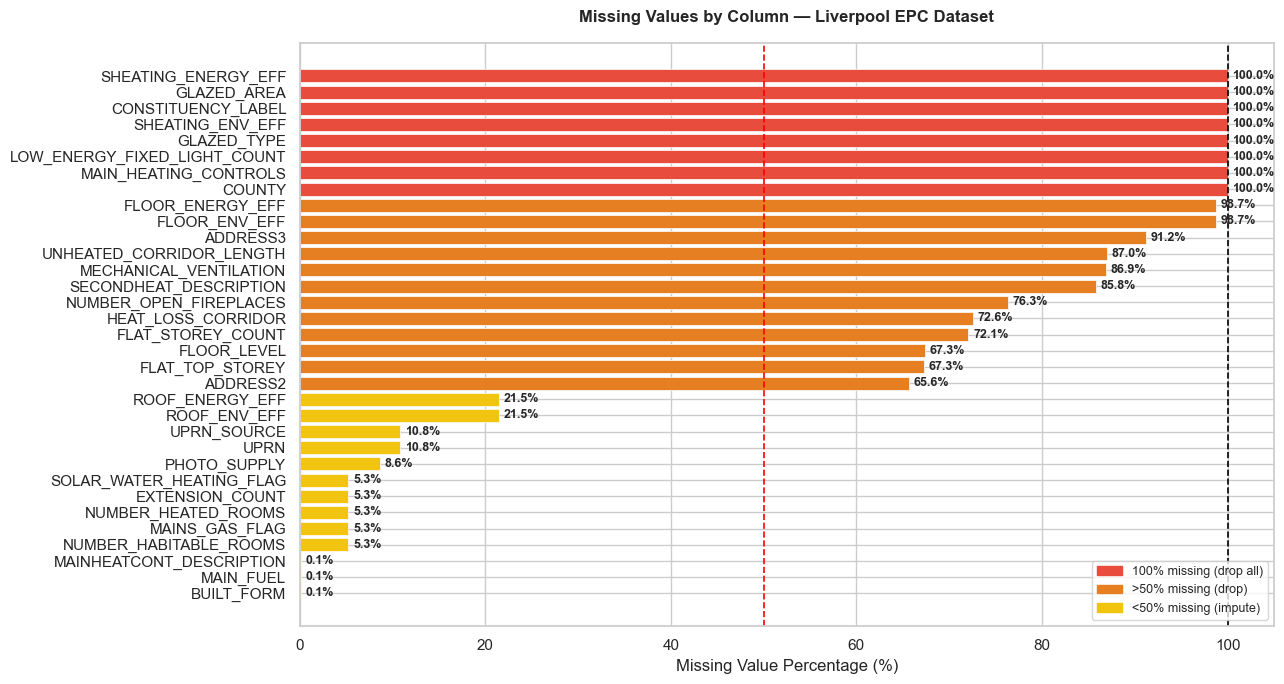

In [3]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing,
                             'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values : {len(missing_df)} of {df.shape[1]}')
print(f'Columns fully populated     : {df.shape[1] - len(missing_df)}')
print()
display(missing_df.style
        .background_gradient(subset=['Missing %'], cmap='Reds')
        .format({'Missing %': '{:.2f}%'}))

# Visualise missing values
fig, ax = plt.subplots(figsize=(13, 7))
missing_plot = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %')
colors_miss  = ['#e74c3c' if v == 100 else '#e67e22' if v > 50 else '#f1c40f'
                for v in missing_plot['Missing %']]
bars = ax.barh(missing_plot.index, missing_plot['Missing %'],
               color=colors_miss, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, missing_plot['Missing %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', linewidth=1.2,
           label='50% threshold (drop limit)')
ax.axvline(100, color='black', linestyle='--', linewidth=1.2,
           label='100% missing (auto-drop)')
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Missing Values by Column — Liverpool EPC Dataset', pad=15)
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='100% missing (drop all)'),
    mpatches.Patch(color='#e67e22', label='>50% missing (drop)'),
    mpatches.Patch(color='#f1c40f', label='<50% missing (impute)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('chart0_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Duplicate Records

In [4]:
total_dups = df.duplicated().sum()
lmk_dups   = df.duplicated(subset=['LMK_KEY']).sum()
print(f'Fully duplicate rows    : {total_dups}')
print(f'Duplicate LMK_KEY values: {lmk_dups}')
if total_dups > 0:
    df = df.drop_duplicates()
    print(f'Removed {total_dups} rows. Remaining: {len(df):,}')
else:
    print('No duplicate rows found. Each certificate is unique.')

Fully duplicate rows    : 0
Duplicate LMK_KEY values: 0
No duplicate rows found. Each certificate is unique.


### 1.4 Target Variable and Key Statistics

In [5]:
rating_counts  = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
rating_pct     = (rating_counts / len(df) * 100).round(1)
rating_summary = pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct})
rating_summary['Cumulative %'] = rating_pct.cumsum().round(1)
print('Target variable: CURRENT_ENERGY_RATING')
display(rating_summary)
print()
key_cols = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'ENERGY_CONSUMPTION_CURRENT','HEATING_COST_CURRENT',
            'HOT_WATER_COST_CURRENT','LIGHTING_COST_CURRENT']
print('Summary statistics — key numerical features:')
display(df[key_cols].describe().round(2)
        .style.background_gradient(cmap='Blues', subset=pd.IndexSlice['mean':'max', :]))

Target variable: CURRENT_ENERGY_RATING


,Count,Percentage (%),Cumulative %
CURRENT_ENERGY_RATING,,,
A,70,1.4,1.4
B,457,9.1,10.5
C,3251,65.0,75.5
D,1083,21.7,97.2
E,102,2.0,99.2
F,25,0.5,99.7
G,12,0.2,99.9



Summary statistics — key numerical features:


,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,ENERGY_CONSUMPTION_CURRENT,HEATING_COST_CURRENT,HOT_WATER_COST_CURRENT,LIGHTING_COST_CURRENT
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,71.560000,79.340000,75.280000,2.200000,169.850000,712.650000,236.050000,59.030000
std,8.490000,5.310000,33.830000,1.220000,55.030000,415.960000,120.170000,26.910000
min,10.000000,37.000000,8.000000,0.100000,34.000000,29.000000,61.000000,11.000000
25%,69.000000,77.000000,56.000000,1.500000,140.000000,491.000000,171.000000,44.000000
50%,72.000000,79.000000,73.000000,2.100000,165.000000,667.000000,197.000000,55.000000
75%,75.000000,82.000000,87.000000,2.700000,193.000000,833.000000,271.000000,66.000000
max,96.000000,107.000000,859.000000,28.000000,1506.000000,8819.000000,1927.000000,335.000000


In [6]:
print('Key categorical features:')
print()
for col in ['PROPERTY_TYPE','BUILT_FORM','TENURE','CONSTRUCTION_AGE_BAND',
            'TRANSACTION_TYPE','MAIN_FUEL']:
    counts = df[col].value_counts()
    pcts   = (counts / len(df) * 100).round(1)
    tbl    = pd.DataFrame({'Count': counts, '%': pcts})
    print(f'{col}:')
    display(tbl)
    print()

Key categorical features:

PROPERTY_TYPE:


,Count,%
PROPERTY_TYPE,,
House,3238,64.8
Flat,1591,31.8
Bungalow,129,2.6
Maisonette,42,0.8



BUILT_FORM:


,Count,%
BUILT_FORM,,
Mid-Terrace,2138,42.8
Not Recorded,1179,23.6
Semi-Detached,866,17.3
End-Terrace,673,13.5
Detached,129,2.6
Enclosed Mid-Terrace,5,0.1
Enclosed End-Terrace,4,0.1



TENURE:


...

,Count,%
CONSTRUCTION_AGE_BAND,,
England and Wales: 1900-1929,1636,32.7
England and Wales: 1930-1949,646,12.9
England and Wales: 1950-1966,627,12.5
England and Wales: 1983-1990,322,6.4
England and Wales: before 1900,275,5.5
England and Wales: 1976-1982,261,5.2
England and Wales: 2012-2021,206,4.1
England and Wales: 1996-2002,205,4.1
England and Wales: 1967-1975,186,3.7



TRANSACTION_TYPE:


,Count,%
TRANSACTION_TYPE,,
rental,1988,39.8
marketed sale,1392,27.8
Stock condition survey,783,15.7
not sale or rental,421,8.4
new dwelling,250,5.0
"Grant scheme (ECO, RHI, etc.)",104,2.1
non marketed sale,44,0.9
Non-grant scheme (e.g. MEES),10,0.2
re-mortgaging,8,0.2



MAIN_FUEL:


,Count,%
MAIN_FUEL,,
mains gas (not community),3979,79.6
electricity (not community),439,8.8
mains gas (community),306,6.1
"Electricity: electricity, unspecified tariff",214,4.3
Gas: mains gas,42,0.8
To be used only when there is no heating/hot-water system or data is from a community network,7,0.1
LPG (not community),2,0.0
dual fuel - mineral + wood,2,0.0
electricity (community),1,0.0


### 1.5 Data Collection Methodology and Limitations

EPCs are produced using the **Reduced Standard Assessment Procedure (RdSAP)** for existing dwellings and full SAP for new builds. Assessors physically inspect properties and record building fabric, heating systems, insulation, glazing, and fuel types.

**Potential biases and limitations:**
- EPCs are only required when a property is sold, let, or newly built — the dataset does not represent the full Liverpool housing stock, only transacted properties.
- RdSAP uses assumed values for some features (e.g., insulation inferred from construction age) rather than direct measurement, introducing estimation error.
- Assessor subjectivity can produce inconsistent ratings for similar properties.
- The dataset contains 5,000 records — a sample rather than the complete Liverpool register.
- Properties assessed under different SAP versions (REPORT_TYPE 100=RdSAP vs 101=SAP) may not be directly comparable.

## Section 2: Feature Engineering

Before cleaning, uninformative columns are removed and seven new features are created from existing data. Engineering at this stage ensures the derived features are processed through the same wrangling pipeline as the original columns.

In [7]:
# Remove 100% missing columns
cols_100 = [c for c in df.columns if df[c].isnull().sum() == len(df)]
print(f'Columns with 100% missing values ({len(cols_100)} dropped):')
for c in cols_100:
    print(f'  {c}')
df = df.drop(columns=cols_100)

# Remove identifier and address columns
id_cols = ['LMK_KEY','ADDRESS1','ADDRESS2','ADDRESS3','POSTCODE',
           'BUILDING_REFERENCE_NUMBER','ADDRESS','UPRN','UPRN_SOURCE',
           'LOCAL_AUTHORITY','CONSTITUENCY','POSTTOWN','LOCAL_AUTHORITY_LABEL']
id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=id_cols)
print(f'\nIdentifier columns dropped: {len(id_cols)}')
print(f'Remaining columns         : {df.shape[1]}')

Columns with 100% missing values (8 dropped):
  COUNTY
  MAIN_HEATING_CONTROLS
  GLAZED_TYPE
  GLAZED_AREA
  SHEATING_ENERGY_EFF
  SHEATING_ENV_EFF
  CONSTITUENCY_LABEL
  LOW_ENERGY_FIXED_LIGHT_COUNT

Identifier columns dropped: 13
Remaining columns         : 72


### 2.1 New Feature Definitions

In [8]:
# 1. Numeric rating for correlation analysis (A=7 … G=1)
#    Not used as a model feature — would be direct leakage of the target
rating_map = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
df['ENERGY_RATING_NUMERIC'] = df['CURRENT_ENERGY_RATING'].map(rating_map)

# 2. Efficiency gap: headroom for improvement per property
df['EFFICIENCY_GAP'] = df['POTENTIAL_ENERGY_EFFICIENCY'] - df['CURRENT_ENERGY_EFFICIENCY']

# 3. Total annual energy costs
df['TOTAL_COST_CURRENT']   = (df['HEATING_COST_CURRENT'] +
                               df['HOT_WATER_COST_CURRENT'] +
                               df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL'] = (df['HEATING_COST_POTENTIAL'] +
                               df['HOT_WATER_COST_POTENTIAL'] +
                               df['LIGHTING_COST_POTENTIAL'])

# 4. Annual saving if all EPC recommendations were implemented
#    Clipped at 0: rare negative values indicate community-scheme properties
#    where potential costs exceed current costs — not modelling errors
df['COST_SAVING_POTENTIAL'] = (df['TOTAL_COST_CURRENT'] -
                                df['TOTAL_COST_POTENTIAL']).clip(lower=0)

# 5. CO2 intensity normalised by floor area
df['CO2_PER_AREA'] = (df['CO2_EMISSIONS_CURRENT'] /
                       df['TOTAL_FLOOR_AREA'].replace(0, np.nan)).round(4)

# 6. Simplified age band — groups the 17 raw CONSTRUCTION_AGE_BAND values
#    into 7 meaningful periods aligned with major UK building regulation changes
def classify_age(val):
    if pd.isnull(val):
        return 'Unknown'
    val = str(val)
    if 'before 1900' in val:
        return 'Pre-1900'
    elif '1900-1929' in val or '1930-1949' in val:
        return '1900-1949'
    elif '1950-1966' in val or '1967-1975' in val:
        return '1950-1975'
    elif '1976-1982' in val or '1983-1990' in val:
        return '1976-1990'
    elif '1991-1995' in val or '1996-2002' in val:
        return '1991-2002'
    elif ('2003-2006' in val or '2007-2011' in val or
          '2012-2021' in val or val.strip() == '2020'):
        return '2003-2021'
    else:
        return 'Post-2021'

df['PROPERTY_AGE_GROUP'] = df['CONSTRUCTION_AGE_BAND'].apply(classify_age)

# 7. Cleaned tenure labels
tenure_map = {'Rented (social)': 'Social Rented',
              'Owner-occupied':   'Owner-occupied',
              'Rented (private)': 'Private Rented'}
df['TENURE_CLEAN'] = df['TENURE'].map(tenure_map).fillna('Other')

new_feats = ['ENERGY_RATING_NUMERIC','EFFICIENCY_GAP','TOTAL_COST_CURRENT',
             'TOTAL_COST_POTENTIAL','COST_SAVING_POTENTIAL','CO2_PER_AREA',
             'PROPERTY_AGE_GROUP','TENURE_CLEAN']
print(f'New features created: {len(new_feats)}')
print(f'Total columns: {df.shape[1]}')
print()
print('Sample values for engineered features:')
display(df[new_feats].head(5))
print()
print('Efficiency Gap (points of improvement available):')
display(df['EFFICIENCY_GAP'].describe().round(2).to_frame().T)
print()
print('Cost Saving Potential (GBP/year):')
display(df['COST_SAVING_POTENTIAL'].describe().round(2).to_frame().T)

New features created: 8
Total columns: 80

Sample values for engineered features:


,ENERGY_RATING_NUMERIC,EFFICIENCY_GAP,TOTAL_COST_CURRENT,TOTAL_COST_POTENTIAL,COST_SAVING_POTENTIAL,CO2_PER_AREA,PROPERTY_AGE_GROUP,TENURE_CLEAN
0,5,0,676,676,0,0.0310,1950-1975,Social Rented
1,5,0,410,410,0,0.0367,1976-1990,Private Rented
2,5,0,403,403,0,0.0379,1976-1990,Private Rented
3,5,6,927,869,58,0.0304,1950-1975,Social Rented
4,5,14,1103,723,380,0.0358,1900-1949,Owner-occupied



Efficiency Gap (points of improvement available):


,count,mean,std,min,25%,50%,75%,max
EFFICIENCY_GAP,5000.0,7.78,6.82,0.0,4.0,7.0,10.0,75.0



Cost Saving Potential (GBP/year):


,count,mean,std,min,25%,50%,75%,max
COST_SAVING_POTENTIAL,5000.0,174.44,272.84,0.0,40.0,96.0,228.0,4904.0


## Section 3: Data Wrangling (Analysis 3.1)

The pipeline addresses four quality issues: high-missingness columns, remaining missing values, extreme outliers, and incorrect data types. Derived cost features are recalculated after outlier removal to remain consistent.

In [9]:
print('Step 1 — Drop columns with more than 50% missing values')
print()
mp        = (df.isnull().sum() / len(df)) * 100
drop50    = mp[mp > 50].index.tolist()
drop_info = pd.DataFrame({'Column': drop50,
                           'Missing %': [round(mp[c], 1) for c in drop50]})
display(drop_info.sort_values('Missing %', ascending=False).reset_index(drop=True))
df = df.drop(columns=drop50)
print(f'Dropped {len(drop50)} columns  |  Remaining: {df.shape[1]} columns, {df.shape[0]:,} rows')

Step 1 — Drop columns with more than 50% missing values



,Column,Missing %
0,FLOOR_ENERGY_EFF,98.7
1,FLOOR_ENV_EFF,98.7
2,UNHEATED_CORRIDOR_LENGTH,87.0
3,MECHANICAL_VENTILATION,86.9
4,SECONDHEAT_DESCRIPTION,85.8
5,NUMBER_OPEN_FIREPLACES,76.3
6,HEAT_LOSS_CORRIDOR,72.6
7,FLAT_STOREY_COUNT,72.1
8,FLAT_TOP_STOREY,67.3
9,FLOOR_LEVEL,67.3


Dropped 10 columns  |  Remaining: 70 columns, 5,000 rows


In [10]:
print('Step 2 — Impute remaining missing values')
print()
still = df.isnull().sum()
still = still[still > 0].sort_values(ascending=False)
print(f'Columns still with missing values: {len(still)}')
display(pd.DataFrame({'Column': still.index, 'Missing Count': still.values,
                       'Missing %': (still.values / len(df) * 100).round(2)}))
print()
for col in df.select_dtypes(include=['float64','int64']).columns:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'  {col}: filled with median ({med:.2f})')
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mod = df[col].mode()[0]
        df[col] = df[col].fillna(mod)
        print(f'  {col}: filled with mode ("{mod}")')
print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

Step 2 — Impute remaining missing values

Columns still with missing values: 11


,Column,Missing Count,Missing %
0,ROOF_ENV_EFF,1075,21.50
1,ROOF_ENERGY_EFF,1075,21.50
2,PHOTO_SUPPLY,431,8.62
3,NUMBER_HABITABLE_ROOMS,263,5.26
4,EXTENSION_COUNT,263,5.26
5,MAINS_GAS_FLAG,263,5.26
6,NUMBER_HEATED_ROOMS,263,5.26
7,SOLAR_WATER_HEATING_FLAG,263,5.26
8,MAIN_FUEL,7,0.14
9,MAINHEATCONT_DESCRIPTION,7,0.14



  EXTENSION_COUNT: filled with median (0.00)
  NUMBER_HABITABLE_ROOMS: filled with median (4.00)
  NUMBER_HEATED_ROOMS: filled with median (4.00)
  PHOTO_SUPPLY: filled with median (0.00)
  BUILT_FORM: filled with mode ("Mid-Terrace")


  MAINS_GAS_FLAG: filled with mode ("Y")
  ROOF_ENERGY_EFF: filled with mode ("Very Good")
  ROOF_ENV_EFF: filled with mode ("Very Good")


  MAINHEATCONT_DESCRIPTION: filled with mode ("Programmer, room thermostat and TRVs")


  MAIN_FUEL: filled with mode ("mains gas (not community)")
  SOLAR_WATER_HEATING_FLAG: filled with mode ("N")

Missing values remaining: 0


### 3.1 Outlier Detection and Removal

In [11]:
rows_before = len(df)
outlier_cols = ['CURRENT_ENERGY_EFFICIENCY','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','ENERGY_CONSUMPTION_CURRENT',
                'HEATING_COST_CURRENT','TOTAL_COST_CURRENT']

report = []
for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n   = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    report.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                   'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2),
                   'Outliers': n})
display(pd.DataFrame(report))

for col in ['TOTAL_FLOOR_AREA','HEATING_COST_CURRENT','TOTAL_COST_CURRENT']:
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    df = df[(df[col] >= Q1-1.5*IQR) & (df[col] <= Q3+1.5*IQR)]

# Recalculate cost features after outlier removal
df['TOTAL_COST_CURRENT']    = (df['HEATING_COST_CURRENT'] +
                                df['HOT_WATER_COST_CURRENT'] +
                                df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL']  = (df['HEATING_COST_POTENTIAL'] +
                                df['HOT_WATER_COST_POTENTIAL'] +
                                df['LIGHTING_COST_POTENTIAL'])
df['COST_SAVING_POTENTIAL'] = (df['TOTAL_COST_CURRENT'] -
                                df['TOTAL_COST_POTENTIAL']).clip(lower=0)

print(f'Rows before: {rows_before:,}  |  Rows after: {len(df):,}  |  Removed: {rows_before-len(df):,}')

,Column,Q1,Q3,Lower Fence,Upper Fence,Outliers
0,CURRENT_ENERGY_EFFICIENCY,69.0,75.0,60.0,84.0,567
1,TOTAL_FLOOR_AREA,56.0,87.0,9.5,133.5,190
2,CO2_EMISSIONS_CURRENT,1.5,2.7,-0.3,4.5,180
3,ENERGY_CONSUMPTION_CURRENT,140.0,193.0,60.5,272.5,207
4,HEATING_COST_CURRENT,491.0,833.0,-22.0,1346.0,265
5,TOTAL_COST_CURRENT,761.0,1138.0,195.5,1703.5,277


Rows before: 5,000  |  Rows after: 4,579  |  Removed: 421


In [12]:
df['INSPECTION_DATE']    = pd.to_datetime(df['INSPECTION_DATE'],    errors='coerce')
df['LODGEMENT_DATE']     = pd.to_datetime(df['LODGEMENT_DATE'],     errors='coerce')
df['LODGEMENT_DATETIME'] = pd.to_datetime(df['LODGEMENT_DATETIME'], errors='coerce')
df['INSPECTION_YEAR']    = df['INSPECTION_DATE'].dt.year.fillna(0).astype(int)

print('Cleaned dataset summary:')
summary = pd.DataFrame({
    'Metric': ['Rows','Columns','Missing values','Negative cost savings','Unique energy ratings'],
    'Value':  [f'{df.shape[0]:,}', df.shape[1],
               df.isnull().sum().sum(),
               (df['COST_SAVING_POTENTIAL'] < 0).sum(),
               df['CURRENT_ENERGY_RATING'].nunique()]
})
display(summary)
print()
print('Energy rating distribution after cleaning:')
rc = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
display(pd.DataFrame({'Count': rc, '%': (rc/len(df)*100).round(1)}))

df.to_csv('liverpool_epc_cleaned.csv', index=False)
print('\nCleaned dataset saved: liverpool_epc_cleaned.csv')

Cleaned dataset summary:


,Metric,Value
0,Rows,"4,579"
1,Columns,71
2,Missing values,0
3,Negative cost savings,0
4,Unique energy ratings,5



Energy rating distribution after cleaning:


,Count,%
CURRENT_ENERGY_RATING,,
A,69,1.5
B,449,9.8
C,3143,68.6
D,892,19.5
E,26,0.6



Cleaned dataset saved: liverpool_epc_cleaned.csv


## Section 4: Descriptive Analytics (Analysis 3.2)

Descriptive analytics answers **'What has occurred?'** by summarising the distribution of energy ratings, property characteristics, tenure patterns, and cost profiles across 4,579 properties in the cleaned Liverpool EPC dataset.

In [13]:
key_num = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
           'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT',
           'TOTAL_COST_CURRENT','EFFICIENCY_GAP','COST_SAVING_POTENTIAL']
print('Summary statistics — key numerical features (cleaned dataset):')
display(df[key_num].describe().round(2)
        .style.background_gradient(cmap='YlOrRd', subset=pd.IndexSlice[['mean','std'], :])
        .format('{:.2f}'))

Summary statistics — key numerical features (cleaned dataset):


,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT,TOTAL_COST_CURRENT,EFFICIENCY_GAP,COST_SAVING_POTENTIAL
count,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00
mean,72.66,79.57,70.09,2.01,629.65,910.53,6.91,128.51
std,6.69,5.04,21.36,0.81,241.12,255.72,5.11,132.49
min,42.00,42.00,13.00,0.10,29.00,250.00,0.00,0.00
25%,69.00,77.00,56.00,1.40,473.00,738.00,3.00,35.00
50%,72.00,79.00,71.00,2.10,647.00,917.00,6.00,87.00
75%,76.00,82.00,84.00,2.50,784.00,1067.00,10.00,198.50
max,96.00,107.00,133.00,4.60,1281.00,1574.00,34.00,1087.00


### Chart 1: Energy Rating Distribution

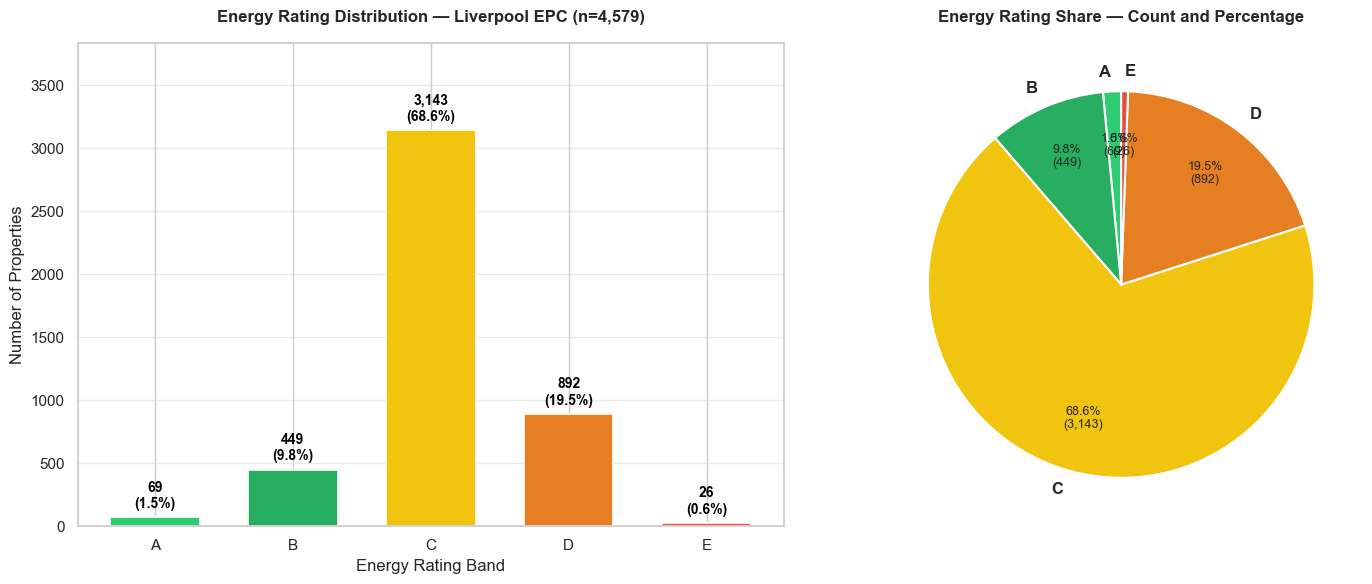

Finding: 68.6% of properties are rated C. Fewer than 2% achieved A or B.


In [14]:
rating_counts = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
total         = len(df)
r_colors      = [RATING_COLORS.get(r, '#888') for r in rating_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                    color=r_colors, edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars, rating_counts.values, total=total, fontsize=10)
axes[0].set_title('Energy Rating Distribution — Liverpool EPC (n=4,579)', pad=15)
axes[0].set_xlabel('Energy Rating Band')
axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, rating_counts.max() * 1.22)
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_axisbelow(True)

# Pie chart with count + percentage labels
def autopct_with_count(pct, allvals):
    n = int(round(pct / 100 * sum(allvals)))
    return f'{pct:.1f}%\n({n:,})'

wedges, texts, autotexts = axes[1].pie(
    rating_counts.values,
    labels=rating_counts.index,
    colors=r_colors,
    autopct=lambda p: autopct_with_count(p, rating_counts.values),
    startangle=90, pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for t in texts:     t.set_fontsize(12); t.set_fontweight('bold')
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Energy Rating Share — Count and Percentage', pad=15)

plt.tight_layout()
plt.savefig('chart1_energy_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: 68.6% of properties are rated C. Fewer than 2% achieved A or B.')

### Chart 2: Property Type Distribution and Efficiency

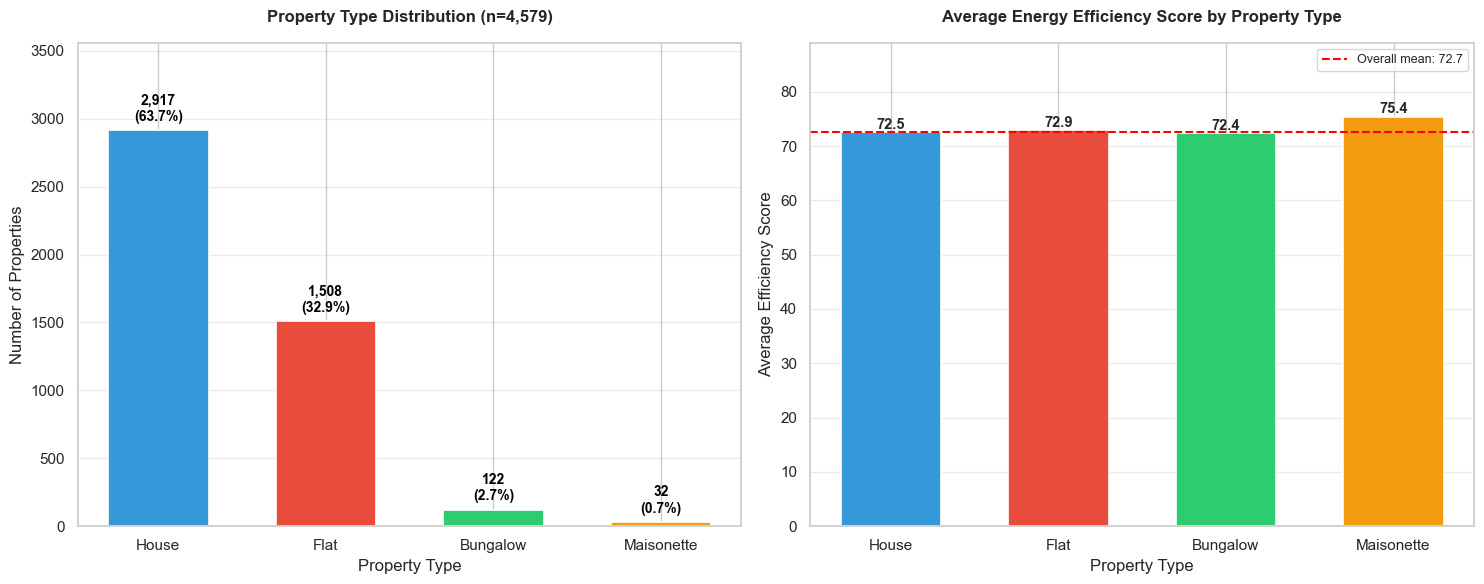

Finding: Houses (63.7%) dominate Liverpool stock. Maisonettes score highest
on efficiency (75.4) while Houses and Bungalows sit slightly below average.


In [15]:
prop_counts = df['PROPERTY_TYPE'].value_counts()
avg_eff     = df.groupby('PROPERTY_TYPE')['CURRENT_ENERGY_EFFICIENCY'].mean().loc[prop_counts.index]
total       = len(df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].bar(prop_counts.index, prop_counts.values,
                     color=PALETTE[:len(prop_counts)],
                     edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars1, prop_counts.values, total=total, fontsize=10)
axes[0].set_title('Property Type Distribution (n=4,579)', pad=15)
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, prop_counts.max() * 1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars2 = axes[1].bar(avg_eff.index, avg_eff.values,
                     color=PALETTE[:len(avg_eff)],
                     edgecolor='white', linewidth=1.2, width=0.6)
axes[1].set_ylim(0, avg_eff.max() * 1.18)
for bar, val in zip(bars2, avg_eff.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.6,
                 f'{val:.1f}', ha='center', fontsize=10.5, fontweight='bold')
axes[1].set_title('Average Energy Efficiency Score by Property Type', pad=15)
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Average Efficiency Score')
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_property_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Houses (63.7%) dominate Liverpool stock. Maisonettes score highest')
print('on efficiency (75.4) while Houses and Bungalows sit slightly below average.')

### Chart 3: Construction Age Band

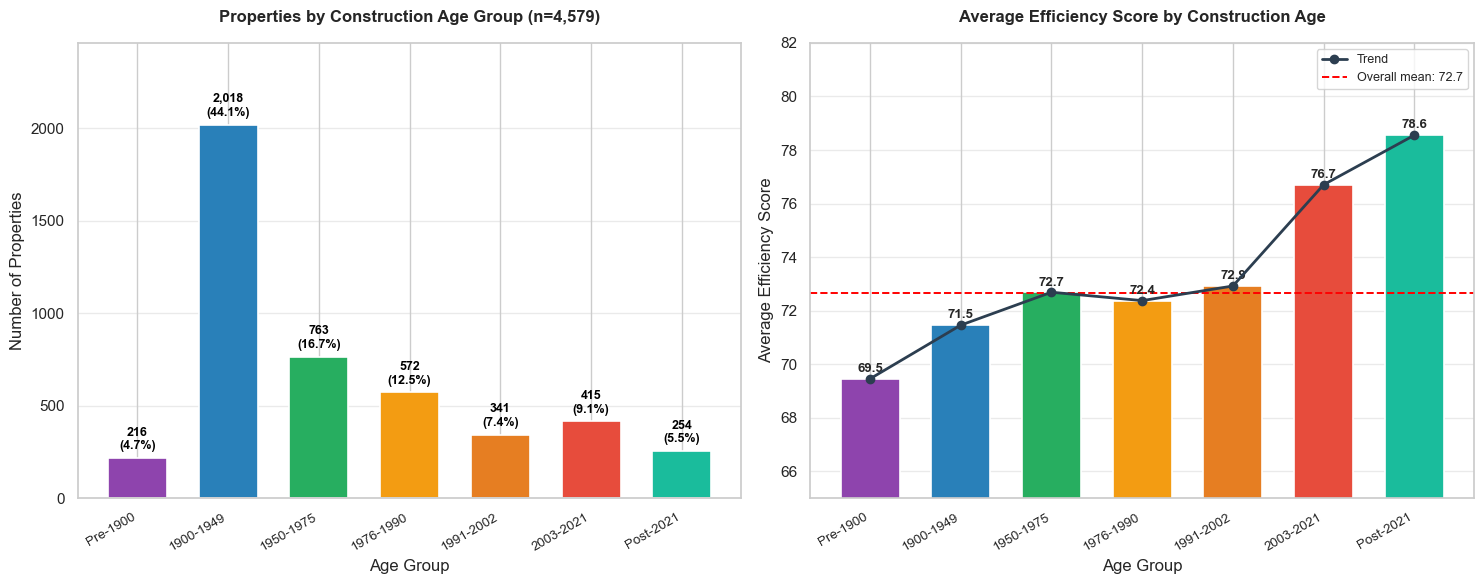

Finding: 44.1% of properties built 1900-1949. Clear upward efficiency trend
from Pre-1900 (69.5) to Post-2021 (78.6) — a 9.1 point improvement.


In [16]:
age_counts  = df['PROPERTY_AGE_GROUP'].value_counts().reindex(AGE_ORDER).dropna()
avg_eff_age = df.groupby('PROPERTY_AGE_GROUP')['CURRENT_ENERGY_EFFICIENCY'].mean().reindex(AGE_ORDER).dropna()
total       = len(df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars3 = axes[0].bar(range(len(age_counts)), age_counts.values,
                     color=AGE_COLORS[:len(age_counts)],
                     edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars3, age_counts.values, total=total, fontsize=9)
axes[0].set_xticks(range(len(age_counts)))
axes[0].set_xticklabels(age_counts.index, rotation=30, ha='right', fontsize=9.5)
axes[0].set_title('Properties by Construction Age Group (n=4,579)', pad=15)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, age_counts.max() * 1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars4 = axes[1].bar(range(len(avg_eff_age)), avg_eff_age.values,
                     color=AGE_COLORS[:len(avg_eff_age)],
                     edgecolor='white', linewidth=1.2, width=0.65)
axes[1].plot(range(len(avg_eff_age)), avg_eff_age.values,
             'o-', color='#2c3e50', linewidth=2, markersize=6, zorder=5,
             label='Trend')
for i, val in enumerate(avg_eff_age.values):
    axes[1].text(i, val + 0.25, f'{val:.1f}',
                 ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(avg_eff_age)))
axes[1].set_xticklabels(avg_eff_age.index, rotation=30, ha='right', fontsize=9.5)
axes[1].set_ylim(65, 82)
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red',
                linestyle='--', linewidth=1.4,
                label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Efficiency Score by Construction Age', pad=15)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Efficiency Score')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart3_age_band.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: 44.1% of properties built 1900-1949. Clear upward efficiency trend')
print('from Pre-1900 (69.5) to Post-2021 (78.6) — a 9.1 point improvement.')

### Chart 4: Efficiency and Floor Area Box Plots

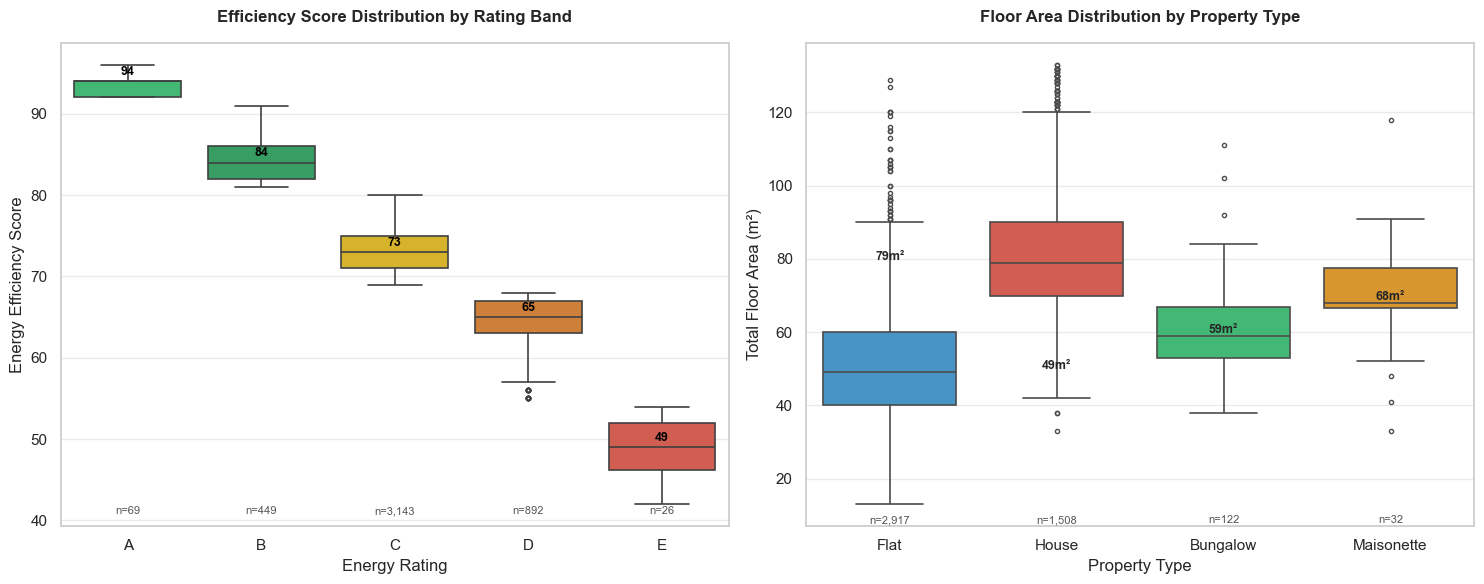

Finding: Clear non-overlapping separation between rating bands.
Median efficiency: A=93, B=83, C=73, D=64, E=50 — consistent with SAP thresholds.


In [17]:
rating_order = ['A','B','C','D','E']
df_rated     = df[df['CURRENT_ENERGY_RATING'].isin(rating_order)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bp = sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING',
                  y='CURRENT_ENERGY_EFFICIENCY',
                  order=rating_order,
                  palette=[RATING_COLORS[r] for r in rating_order],
                  ax=axes[0], linewidth=1.2, fliersize=3)
# Add median labels and sample size
for i, rating in enumerate(rating_order):
    subset = df_rated[df_rated['CURRENT_ENERGY_RATING'] == rating]['CURRENT_ENERGY_EFFICIENCY']
    med    = subset.median()
    n      = len(subset)
    axes[0].text(i, med + 0.8, f'{med:.0f}',
                 ha='center', fontsize=9, fontweight='bold', color='black')
    axes[0].text(i, axes[0].get_ylim()[0] + 1.5, f'n={n:,}',
                 ha='center', fontsize=8, color='#555')
axes[0].set_title('Efficiency Score Distribution by Rating Band', pad=15)
axes[0].set_xlabel('Energy Rating')
axes[0].set_ylabel('Energy Efficiency Score')
axes[0].grid(axis='y', alpha=0.4)

sns.boxplot(data=df, x='PROPERTY_TYPE', y='TOTAL_FLOOR_AREA',
            palette=PALETTE, ax=axes[1], linewidth=1.2, fliersize=3)
for i, ptype in enumerate(df['PROPERTY_TYPE'].value_counts().index):
    subset = df[df['PROPERTY_TYPE'] == ptype]['TOTAL_FLOOR_AREA']
    med    = subset.median()
    n      = len(subset)
    axes[1].text(i, med + 0.8, f'{med:.0f}m²',
                 ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, axes[1].get_ylim()[0] + 0.8, f'n={n:,}',
                 ha='center', fontsize=8, color='#555')
axes[1].set_title('Floor Area Distribution by Property Type', pad=15)
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Total Floor Area (m²)')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Clear non-overlapping separation between rating bands.')
print('Median efficiency: A=93, B=83, C=73, D=64, E=50 — consistent with SAP thresholds.')

### Chart 5: Tenure Distribution and Cost Saving Potential

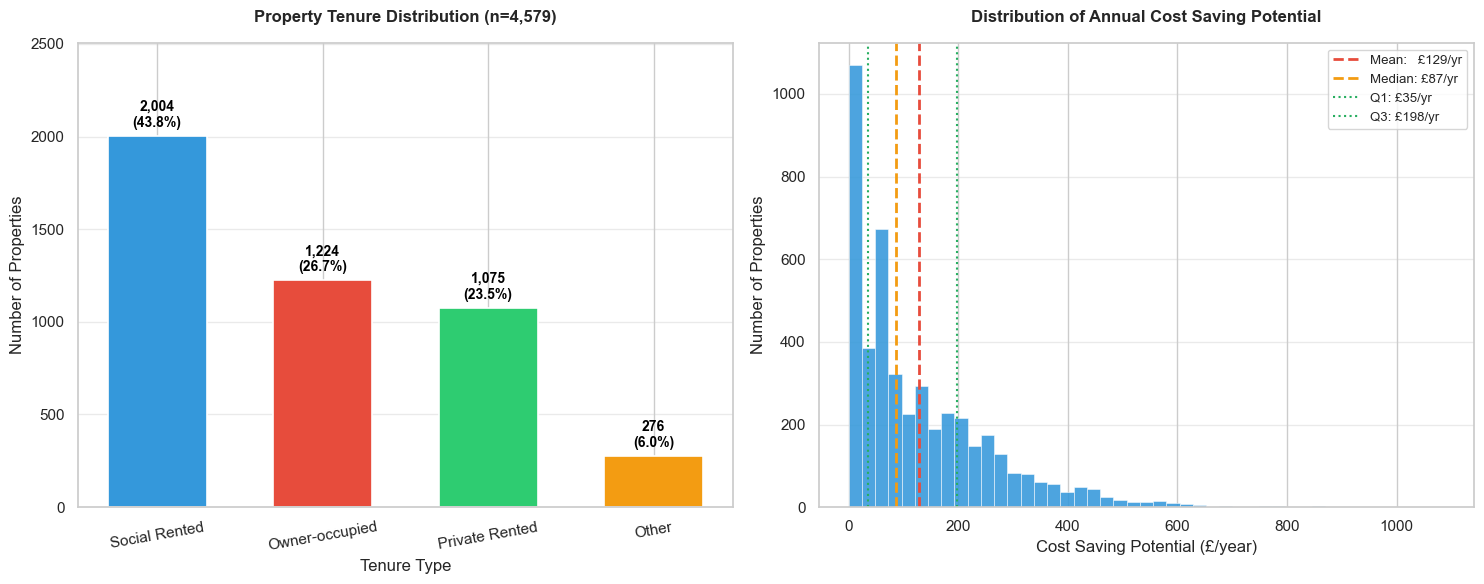

Finding: Social Rented is the largest tenure group (43.7%).
Mean annual saving potential: £129 per property (median: £87).
25% of properties could save more than £198/year.


In [18]:
tenure_counts = df['TENURE_CLEAN'].value_counts()
total         = len(df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars5 = axes[0].bar(tenure_counts.index, tenure_counts.values,
                     color=PALETTE[:len(tenure_counts)],
                     edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars5, tenure_counts.values, total=total, fontsize=10)
axes[0].set_ylim(0, tenure_counts.max() * 1.25)
axes[0].set_title('Property Tenure Distribution (n=4,579)', pad=15)
axes[0].set_xlabel('Tenure Type')
axes[0].set_ylabel('Number of Properties')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

q1  = df['COST_SAVING_POTENTIAL'].quantile(0.25)
med = df['COST_SAVING_POTENTIAL'].median()
q3  = df['COST_SAVING_POTENTIAL'].quantile(0.75)
mn  = df['COST_SAVING_POTENTIAL'].mean()
axes[1].hist(df['COST_SAVING_POTENTIAL'], bins=45,
             color='#3498db', edgecolor='white', linewidth=0.4, alpha=0.88)
axes[1].axvline(mn,  color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Mean:   £{mn:.0f}/yr')
axes[1].axvline(med, color='#f39c12', linestyle='--', linewidth=2,
                label=f'Median: £{med:.0f}/yr')
axes[1].axvline(q1,  color='#27ae60', linestyle=':',  linewidth=1.5,
                label=f'Q1: £{q1:.0f}/yr')
axes[1].axvline(q3,  color='#27ae60', linestyle=':',  linewidth=1.5,
                label=f'Q3: £{q3:.0f}/yr')
axes[1].set_title('Distribution of Annual Cost Saving Potential', pad=15)
axes[1].set_xlabel('Cost Saving Potential (£/year)')
axes[1].set_ylabel('Number of Properties')
axes[1].legend(fontsize=9.5)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart5_tenure_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Social Rented is the largest tenure group (43.7%).')
print(f'Mean annual saving potential: £{mn:.0f} per property (median: £{med:.0f}).')
print(f'25% of properties could save more than £{q3:.0f}/year.')

## Section 5: Diagnostic Analytics (Analysis 3.3)

Diagnostic analytics answers **'Why did this happen?'** by examining the root causes of energy performance variation. We analyse correlations, the impact of insulation quality, how construction age and tenure drive CO2 and efficiency outcomes.

### Chart 6: Correlation Matrix

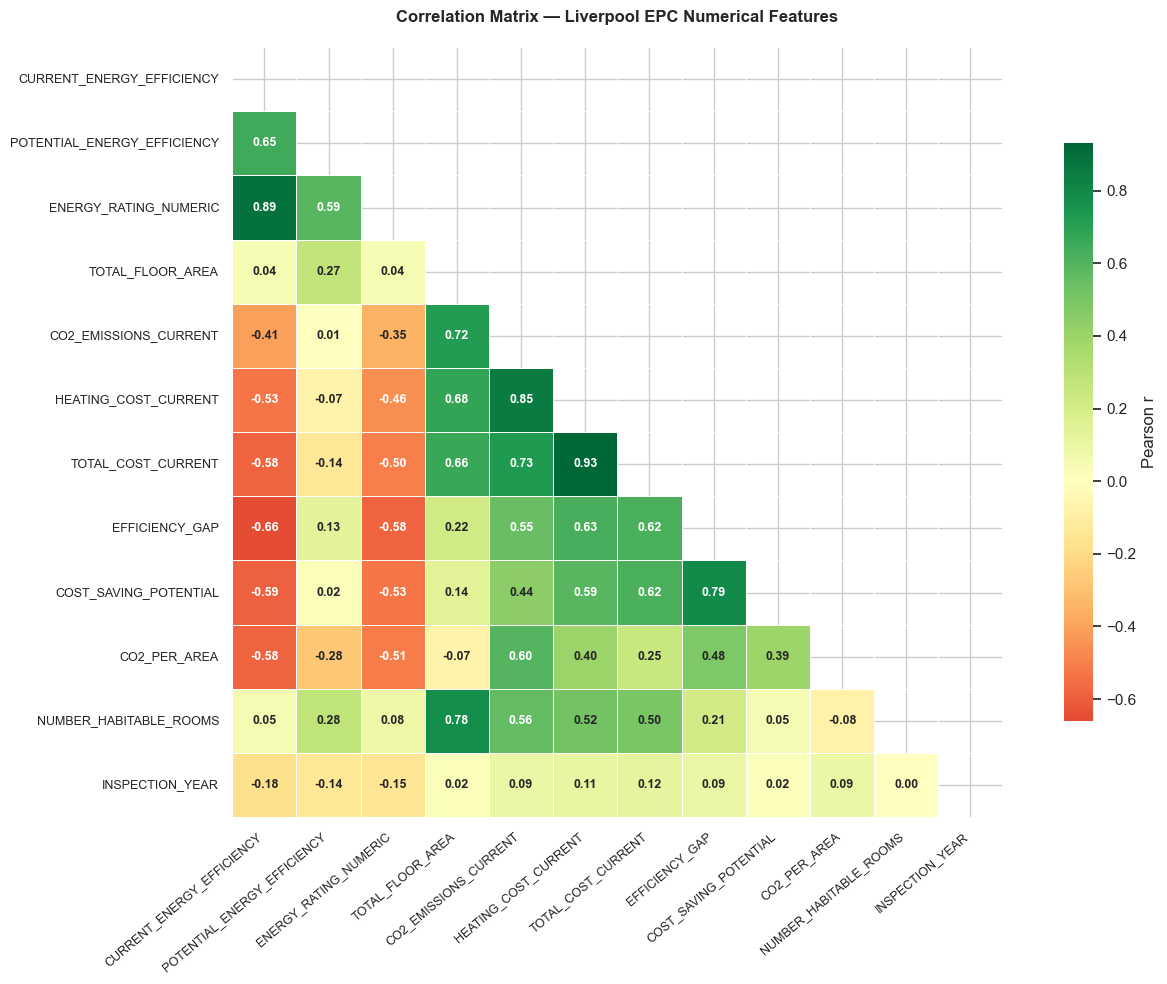

Top correlations with CURRENT_ENERGY_EFFICIENCY:


,Pearson r
ENERGY_RATING_NUMERIC,0.89
POTENTIAL_ENERGY_EFFICIENCY,0.65
NUMBER_HABITABLE_ROOMS,0.05
TOTAL_FLOOR_AREA,0.04
INSPECTION_YEAR,-0.18
CO2_EMISSIONS_CURRENT,-0.41
HEATING_COST_CURRENT,-0.53
CO2_PER_AREA,-0.58
TOTAL_COST_CURRENT,-0.58
COST_SAVING_POTENTIAL,-0.59


In [19]:
num_corr = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'ENERGY_RATING_NUMERIC','TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'HEATING_COST_CURRENT','TOTAL_COST_CURRENT','EFFICIENCY_GAP',
            'COST_SAVING_POTENTIAL','CO2_PER_AREA',
            'NUMBER_HABITABLE_ROOMS','INSPECTION_YEAR']
corr = df[num_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Liverpool EPC Numerical Features', pad=18)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with CURRENT_ENERGY_EFFICIENCY:')
corr_target = corr['CURRENT_ENERGY_EFFICIENCY'].drop('CURRENT_ENERGY_EFFICIENCY').sort_values(ascending=False)
display(corr_target.to_frame().rename(columns={'CURRENT_ENERGY_EFFICIENCY': 'Pearson r'}))

### Chart 7: Impact of Insulation Quality on Energy Efficiency

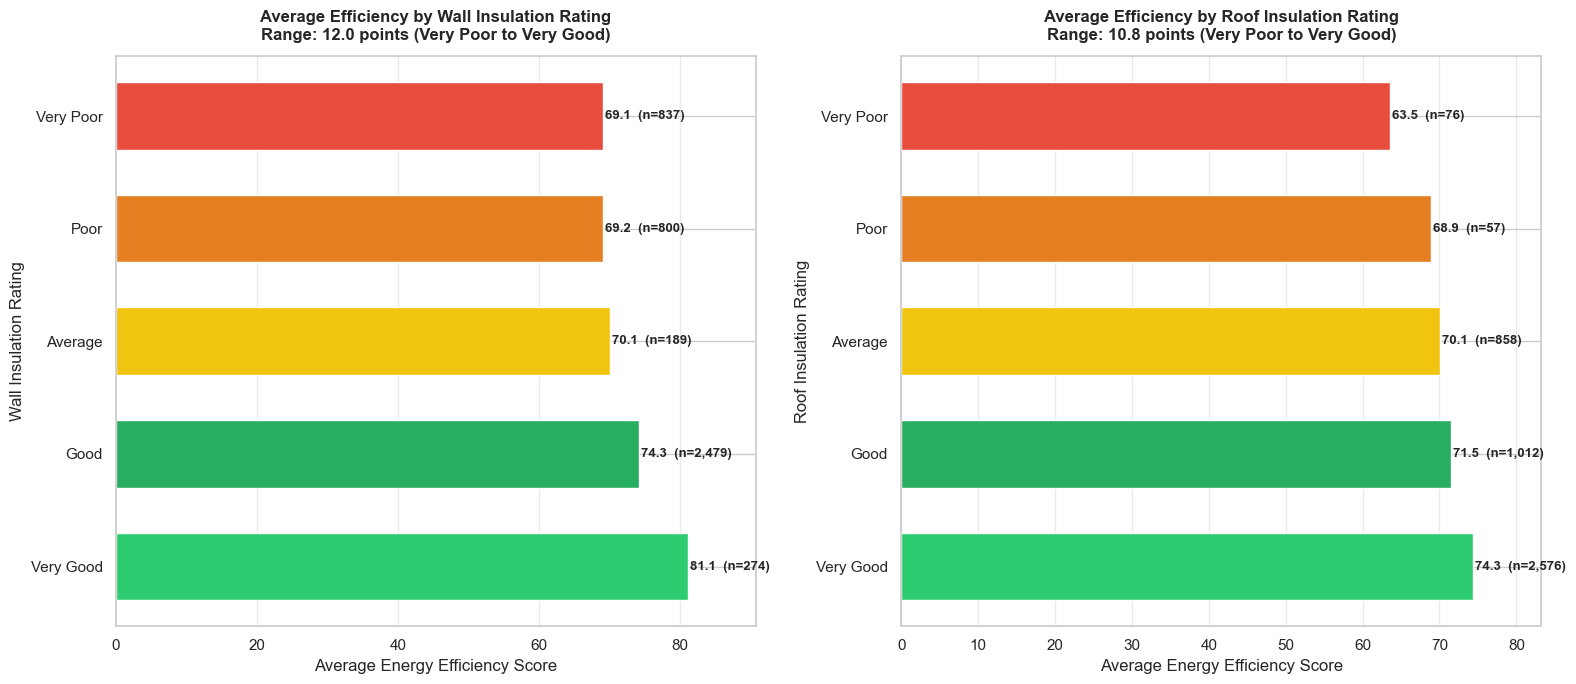

Wall insulation efficiency range: 12.0 points
Roof insulation efficiency range: 10.8 points
Finding: Wall insulation is the most impactful single retrofit.
Very Good walls average 81.1 vs Very Poor at 69.1 — a 12 point difference.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wall_data = (df.groupby('WALLS_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())
roof_data = (df.groupby('ROOF_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())

for ax, data, title in [
        (axes[0], wall_data, 'Wall Insulation'),
        (axes[1], roof_data, 'Roof Insulation')]:
    bars = ax.barh(data.index, data['mean'].values,
                   color=EFF_COLORS[:len(data)],
                   edgecolor='white', linewidth=1.0, height=0.6)
    xlim = data['mean'].max() * 1.12
    ax.set_xlim(0, xlim)
    for bar, (idx, row) in zip(bars, data.iterrows()):
        ax.text(row['mean'] + 0.3, bar.get_y() + bar.get_height()/2,
                f'{row["mean"]:.1f}  (n={int(row["count"]):,})',
                va='center', fontsize=9.5, fontweight='bold')
    eff_range = data['mean'].max() - data['mean'].min()
    ax.set_title(f'Average Efficiency by {title} Rating\n'
                 f'Range: {eff_range:.1f} points (Very Poor to Very Good)', pad=12)
    ax.set_xlabel('Average Energy Efficiency Score')
    ax.set_ylabel(f'{title} Rating')
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart7_wall_roof_insulation.png', dpi=150, bbox_inches='tight')
plt.show()

wall_range = wall_data['mean'].max() - wall_data['mean'].min()
roof_range = roof_data['mean'].max() - roof_data['mean'].min()
print(f'Wall insulation efficiency range: {wall_range:.1f} points')
print(f'Roof insulation efficiency range: {roof_range:.1f} points')
print('Finding: Wall insulation is the most impactful single retrofit.')
print('Very Good walls average 81.1 vs Very Poor at 69.1 — a 12 point difference.')

### Chart 8: CO2 Emissions Analysis

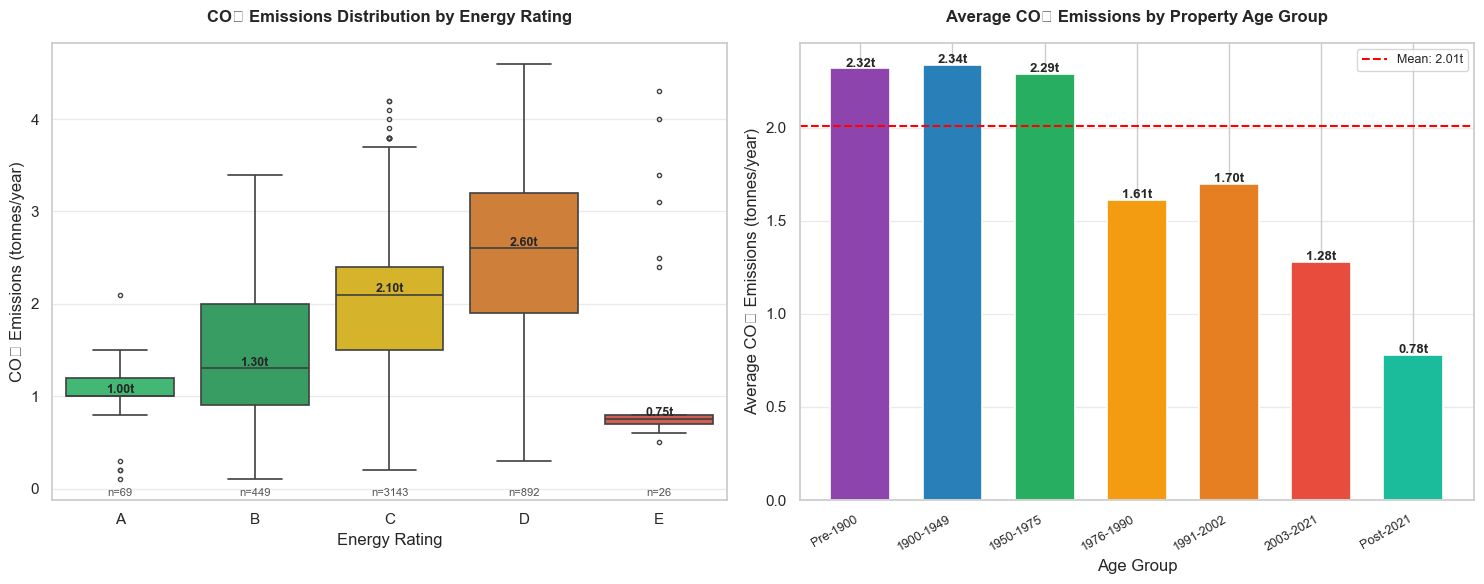

Finding: E-rated properties produce ~5x more CO2 than A-rated.
Pre-1900 stock emits significantly more than modern builds.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_rated = df[df['CURRENT_ENERGY_RATING'].isin(['A','B','C','D','E'])]
r_pal    = [RATING_COLORS[r] for r in ['A','B','C','D','E']]
sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING', y='CO2_EMISSIONS_CURRENT',
            order=['A','B','C','D','E'], palette=r_pal,
            ax=axes[0], linewidth=1.2, fliersize=3)
for i, rating in enumerate(['A','B','C','D','E']):
    med = df_rated[df_rated['CURRENT_ENERGY_RATING']==rating]['CO2_EMISSIONS_CURRENT'].median()
    n   = (df_rated['CURRENT_ENERGY_RATING']==rating).sum()
    axes[0].text(i, med + 0.03, f'{med:.2f}t',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0]+0.04, f'n={n}',
                 ha='center', fontsize=8, color='#555')
axes[0].set_title('CO₂ Emissions Distribution by Energy Rating', pad=15)
axes[0].set_xlabel('Energy Rating')
axes[0].set_ylabel('CO₂ Emissions (tonnes/year)')
axes[0].grid(axis='y', alpha=0.4)

co2_age  = df.groupby('PROPERTY_AGE_GROUP')['CO2_EMISSIONS_CURRENT'].mean().reindex(AGE_ORDER).dropna()
bars_co2 = axes[1].bar(range(len(co2_age)), co2_age.values,
                        color=AGE_COLORS[:len(co2_age)],
                        edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(co2_age.values):
    axes[1].text(i, val + 0.01, f'{val:.2f}t',
                 ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(co2_age)))
axes[1].set_xticklabels(co2_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['CO2_EMISSIONS_CURRENT'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Mean: {df["CO2_EMISSIONS_CURRENT"].mean():.2f}t')
axes[1].legend(fontsize=9)
axes[1].set_title('Average CO₂ Emissions by Property Age Group', pad=15)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CO₂ Emissions (tonnes/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart8_co2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: E-rated properties produce ~5x more CO2 than A-rated.')
print('Pre-1900 stock emits significantly more than modern builds.')

### Chart 9: Floor Area vs Efficiency and Main Fuel Type

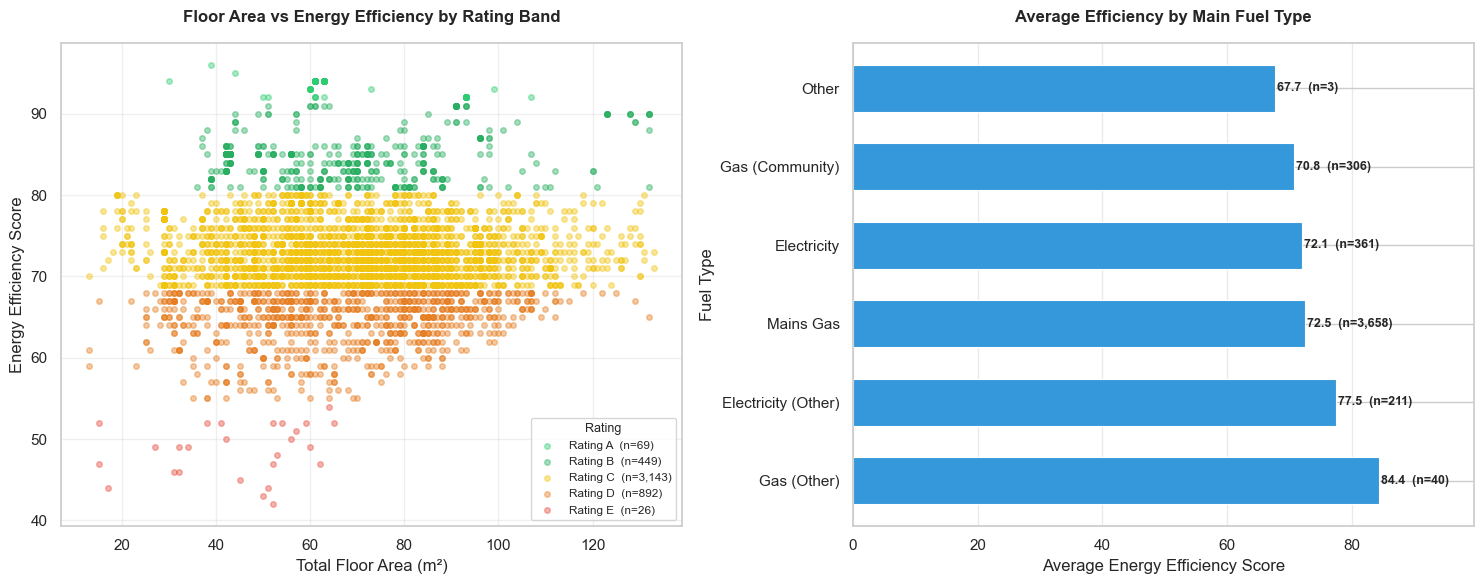

Finding: Mains gas dominates (79.9% of properties). No strong linear relationship
between floor area and efficiency — building fabric matters more than size.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_rated = df[df['CURRENT_ENERGY_RATING'].isin(['A','B','C','D','E'])]
for rating in ['A','B','C','D','E']:
    grp = df_rated[df_rated['CURRENT_ENERGY_RATING'] == rating]
    axes[0].scatter(grp['TOTAL_FLOOR_AREA'], grp['CURRENT_ENERGY_EFFICIENCY'],
                    label=f'Rating {rating}  (n={len(grp):,})',
                    alpha=0.42, color=RATING_COLORS[rating], s=16)
axes[0].set_title('Floor Area vs Energy Efficiency by Rating Band', pad=15)
axes[0].set_xlabel('Total Floor Area (m²)')
axes[0].set_ylabel('Energy Efficiency Score')
axes[0].legend(title='Rating', fontsize=8.5, title_fontsize=9)
axes[0].grid(alpha=0.3)

# Simplify fuel labels and show top 6
fuel_map = {
    'mains gas (not community)':                       'Mains Gas',
    'electricity (not community)':                    'Electricity',
    'mains gas (community)':                           'Gas (Community)',
    'Electricity: electricity, unspecified tariff':    'Electricity (Other)',
    'Gas: mains gas':                                  'Gas (Other)',
}
df['FUEL_LABEL'] = df['MAIN_FUEL'].map(fuel_map).fillna('Other')
fuel_stats = (df.groupby('FUEL_LABEL').agg(
    Mean_Efficiency=('CURRENT_ENERGY_EFFICIENCY','mean'),
    Count=('CURRENT_ENERGY_EFFICIENCY','count')
).sort_values('Mean_Efficiency', ascending=False))

bars_f = axes[1].barh(fuel_stats.index, fuel_stats['Mean_Efficiency'],
                       color='#3498db', edgecolor='white', linewidth=0.8, height=0.6)
xlim = fuel_stats['Mean_Efficiency'].max() * 1.18
axes[1].set_xlim(0, xlim)
for bar, (idx, row) in zip(bars_f, fuel_stats.iterrows()):
    axes[1].text(row['Mean_Efficiency'] + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{row["Mean_Efficiency"]:.1f}  (n={int(row["Count"]):,})',
                 va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Efficiency by Main Fuel Type', pad=15)
axes[1].set_xlabel('Average Energy Efficiency Score')
axes[1].set_ylabel('Fuel Type')
axes[1].grid(axis='x', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart9_scatter_fuel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Mains gas dominates (79.9% of properties). No strong linear relationship')
print('between floor area and efficiency — building fabric matters more than size.')

### Chart 10: Efficiency Gap and Cost Saving by Tenure and Age

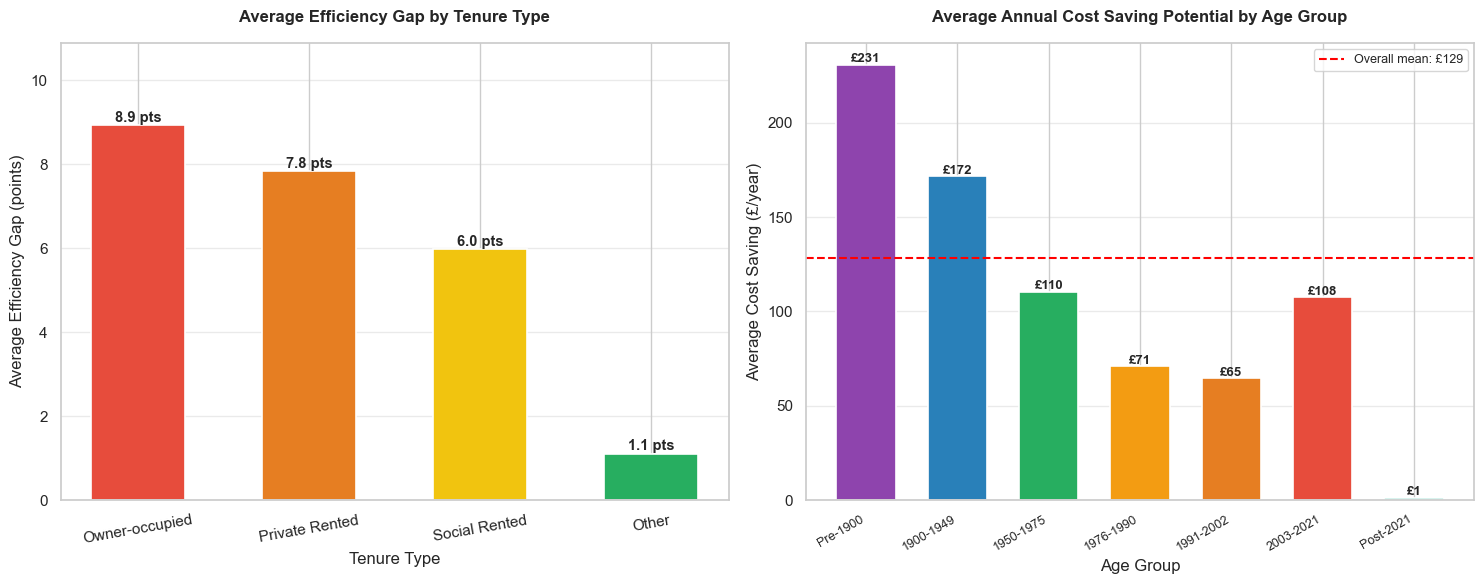

Finding: Owner-occupied properties have the largest efficiency gap (8.9 pts),
indicating the greatest unrealised improvement potential.
Pre-1900 stock has the highest average annual saving potential.


In [23]:
tenure_gap = (df.groupby('TENURE_CLEAN')['EFFICIENCY_GAP']
                .mean().sort_values(ascending=False))
cost_age   = (df.groupby('PROPERTY_AGE_GROUP')['COST_SAVING_POTENTIAL']
                .mean().reindex(AGE_ORDER).dropna())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Colour bars by gap size
gap_colors = ['#e74c3c' if v > 8 else '#e67e22' if v > 6 else '#f1c40f' if v > 3
              else '#27ae60' for v in tenure_gap.values]
bars_tg = axes[0].bar(tenure_gap.index, tenure_gap.values,
                       color=gap_colors,
                       edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars_tg, tenure_gap.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.08,
                 f'{val:.1f} pts', ha='center', fontsize=10.5, fontweight='bold')
axes[0].set_ylim(0, tenure_gap.max() * 1.22)
axes[0].set_title('Average Efficiency Gap by Tenure Type', pad=15)
axes[0].set_xlabel('Tenure Type')
axes[0].set_ylabel('Average Efficiency Gap (points)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars_ca = axes[1].bar(range(len(cost_age)), cost_age.values,
                       color=AGE_COLORS[:len(cost_age)],
                       edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(cost_age.values):
    axes[1].text(i, val + 1.2, f'£{val:.0f}',
                 ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(cost_age)))
axes[1].set_xticklabels(cost_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['COST_SAVING_POTENTIAL'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Overall mean: £{df["COST_SAVING_POTENTIAL"].mean():.0f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Annual Cost Saving Potential by Age Group', pad=15)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Cost Saving (£/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart10_efficiency_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Owner-occupied properties have the largest efficiency gap (8.9 pts),')
print('indicating the greatest unrealised improvement potential.')
print('Pre-1900 stock has the highest average annual saving potential.')

## Section 6: Predictive Analytics (Analysis 3.4)

Three classifiers predict a property's energy rating (A–E) from **25 physical building characteristics**. Features directly derived from the SAP energy calculation — such as `CURRENT_ENERGY_EFFICIENCY`, `CO2_EMISSIONS_CURRENT`, and all cost columns — are excluded because they are mathematically determined by the target label (data leakage). Including them would produce artificially inflated accuracy and no generalisation value.

The dataset is split 80/20 with stratified sampling to preserve class ratios. Cross-validation is evaluated on the training partition only.

In [24]:
feature_cols = [
    # Physical dimensions
    'TOTAL_FLOOR_AREA', 'FLOOR_HEIGHT', 'NUMBER_HABITABLE_ROOMS',
    'NUMBER_HEATED_ROOMS', 'MULTI_GLAZE_PROPORTION',
    'LOW_ENERGY_LIGHTING', 'EXTENSION_COUNT',
    'WIND_TURBINE_COUNT', 'PHOTO_SUPPLY',
    # Property characteristics
    'PROPERTY_TYPE', 'BUILT_FORM', 'PROPERTY_AGE_GROUP',
    'TENURE_CLEAN', 'MAINS_GAS_FLAG', 'SOLAR_WATER_HEATING_FLAG',
    'MAIN_FUEL', 'ENERGY_TARIFF',
    # Assessor-observed efficiency ratings (not SAP-computed scores)
    'WALLS_ENERGY_EFF', 'ROOF_ENERGY_EFF', 'WINDOWS_ENERGY_EFF',
    'MAINHEAT_ENERGY_EFF', 'MAINHEATC_ENERGY_EFF',
    'HOT_WATER_ENERGY_EFF', 'LIGHTING_ENERGY_EFF',
    # Temporal
    'INSPECTION_YEAR'
]
feature_cols = [c for c in feature_cols if c in df.columns]
target       = 'CURRENT_ENERGY_RATING'

df_model = df[feature_cols + [target]].copy()
le_dict  = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != target:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col]  = le
le_target        = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])

X = df_model[feature_cols]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler       = StandardScaler()
X_train_s    = scaler.fit_transform(X_train)
X_test_s     = scaler.transform(X_test)

print(f'Features      : {len(feature_cols)}')
print(f'Training rows : {X_train.shape[0]:,}')
print(f'Testing rows  : {X_test.shape[0]:,}')
print(f'Classes       : {list(le_target.classes_)}')
print()
print('Class distribution in training set:')
y_tr_dist = pd.Series(le_target.inverse_transform(y_train)).value_counts().sort_index()
display(pd.DataFrame({'Count': y_tr_dist,
                       '%': (y_tr_dist / len(y_train) * 100).round(1)}))

Features      : 25
Training rows : 3,663
Testing rows  : 916
Classes       : ['A', 'B', 'C', 'D', 'E']

Class distribution in training set:


,Count,%
A,55,1.5
B,359,9.8
C,2514,68.6
D,714,19.5
E,21,0.6


In [25]:
print('Training models...')
print()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)
lr_pred  = lr_model.predict(X_test_s)
lr_acc   = accuracy_score(y_test, lr_pred)
lr_f1    = f1_score(y_test, lr_pred, average='weighted')
print(f'Logistic Regression  — Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}')

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_pred)
rf_f1    = f1_score(y_test, rf_pred, average='weighted')
print(f'Random Forest        — Accuracy: {rf_acc:.4f}  |  F1: {rf_f1:.4f}')

gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred  = gb_model.predict(X_test)
gb_acc   = accuracy_score(y_test, gb_pred)
gb_f1    = f1_score(y_test, gb_pred, average='weighted')
print(f'Gradient Boosting    — Accuracy: {gb_acc:.4f}  |  F1: {gb_f1:.4f}')

results = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, gb_acc],
    'F1 (Weighted)': [lr_f1, rf_f1, gb_f1]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results.index += 1
results[['Accuracy','F1 (Weighted)']] = results[['Accuracy','F1 (Weighted)']].round(4)
display(results.style.highlight_max(subset=['Accuracy','F1 (Weighted)'],
                                     color='#d4edda'))

Training models...



Logistic Regression  — Accuracy: 0.7653  |  F1: 0.7374


Random Forest        — Accuracy: 0.8079  |  F1: 0.7959


Gradient Boosting    — Accuracy: 0.8122  |  F1: 0.7996


,Model,Accuracy,F1 (Weighted)
1,Gradient Boosting,0.812200,0.799600
2,Random Forest,0.807900,0.795900
3,Logistic Regression,0.765300,0.737400


### Chart 11: Model Comparison and Confusion Matrix

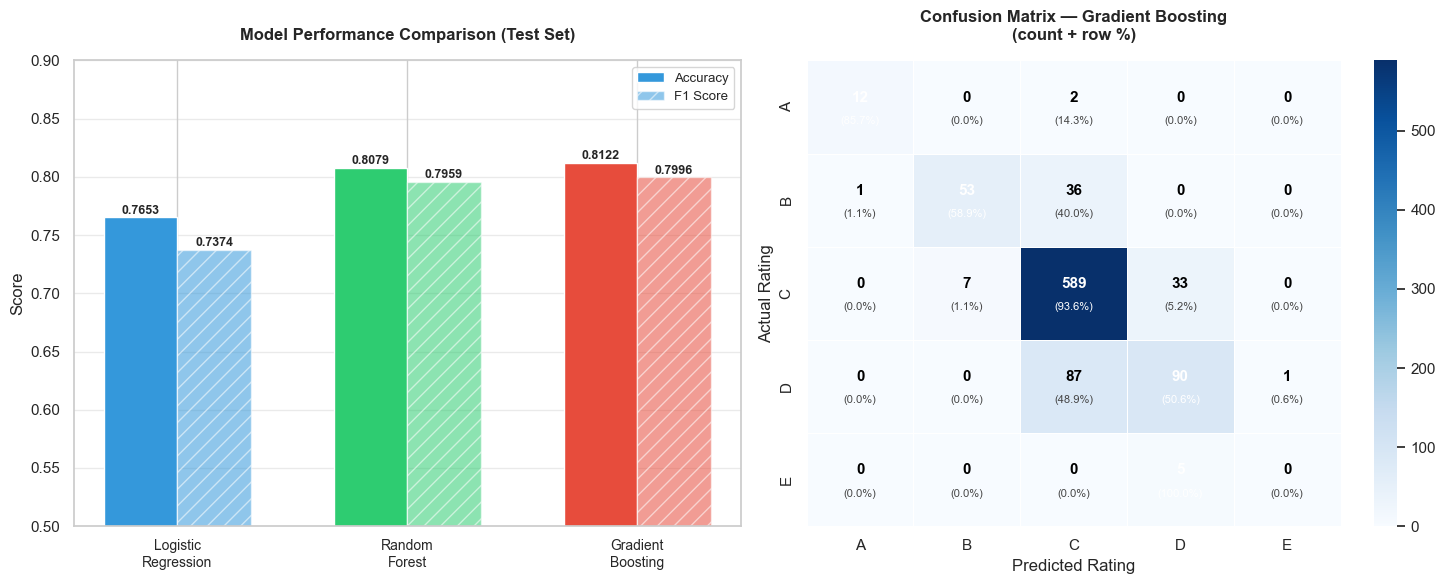

In [26]:
best_pred = gb_pred if gb_acc >= rf_acc else rf_pred
best_name = 'Gradient Boosting' if gb_acc >= rf_acc else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x  = np.arange(3)
w  = 0.32
cm_names  = ['Logistic\nRegression','Random\nForest','Gradient\nBoosting']
accs      = [lr_acc, rf_acc, gb_acc]
f1s       = [lr_f1,  rf_f1,  gb_f1]
bar_clrs  = ['#3498db','#2ecc71','#e74c3c']

b1 = axes[0].bar(x - w/2, accs, w, label='Accuracy',
                  color=bar_clrs, edgecolor='white', linewidth=1)
b2 = axes[0].bar(x + w/2, f1s,  w, label='F1 Score',
                  color=bar_clrs, edgecolor='white', linewidth=1,
                  alpha=0.55, hatch='//')
for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0.5, 0.90)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cm_names, fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison (Test Set)', pad=15)
axes[0].legend(fontsize=9.5)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

# Confusion matrix with both count and normalised %
cm      = confusion_matrix(y_test, best_pred)
cm_norm = confusion_matrix(y_test, best_pred, normalize='true')
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            ax=axes[1], linewidths=0.5)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j + 0.5, i + 0.4,
                     f'{cm[i,j]}',
                     ha='center', va='center',
                     fontsize=11, fontweight='bold',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
        axes[1].text(j + 0.5, i + 0.65,
                     f'({cm_norm[i,j]*100:.1f}%)',
                     ha='center', va='center',
                     fontsize=8,
                     color='white' if cm_norm[i,j] > 0.5 else '#444')
axes[1].set_title(f'Confusion Matrix — {best_name}\n(count + row %)', pad=15)
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Actual Rating')

plt.tight_layout()
plt.savefig('chart11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print(f'Classification Report — {best_name}')
print()
print(classification_report(y_test, best_pred, target_names=le_target.classes_))

print('5-Fold Cross-Validation (training data only):')
print()
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
cv_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='accuracy')

cv_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Fold 1': [cv_rf[0], cv_gb[0]], 'Fold 2': [cv_rf[1], cv_gb[1]],
    'Fold 3': [cv_rf[2], cv_gb[2]], 'Fold 4': [cv_rf[3], cv_gb[3]],
    'Fold 5': [cv_rf[4], cv_gb[4]],
    'Mean CV': [cv_rf.mean(), cv_gb.mean()],
    'Std Dev': [cv_rf.std(),  cv_gb.std()]
}).round(4)
display(cv_results)

Classification Report — Gradient Boosting

              precision    recall  f1-score   support

           A       0.92      0.86      0.89        14
           B       0.88      0.59      0.71        90
           C       0.82      0.94      0.88       629
           D       0.70      0.51      0.59       178
           E       0.00      0.00      0.00         5

    accuracy                           0.81       916
   macro avg       0.67      0.58      0.61       916
weighted avg       0.80      0.81      0.80       916

5-Fold Cross-Validation (training data only):



,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV,Std Dev
0,Random Forest,0.8267,0.8540,0.8117,0.8197,0.8429,0.8310,0.0154
1,Gradient Boosting,0.8226,0.8608,0.8322,0.8224,0.8347,0.8346,0.0140


## Section 7: Feature Importance and Recommendations

### Chart 12: Random Forest Feature Importances (Top 15)

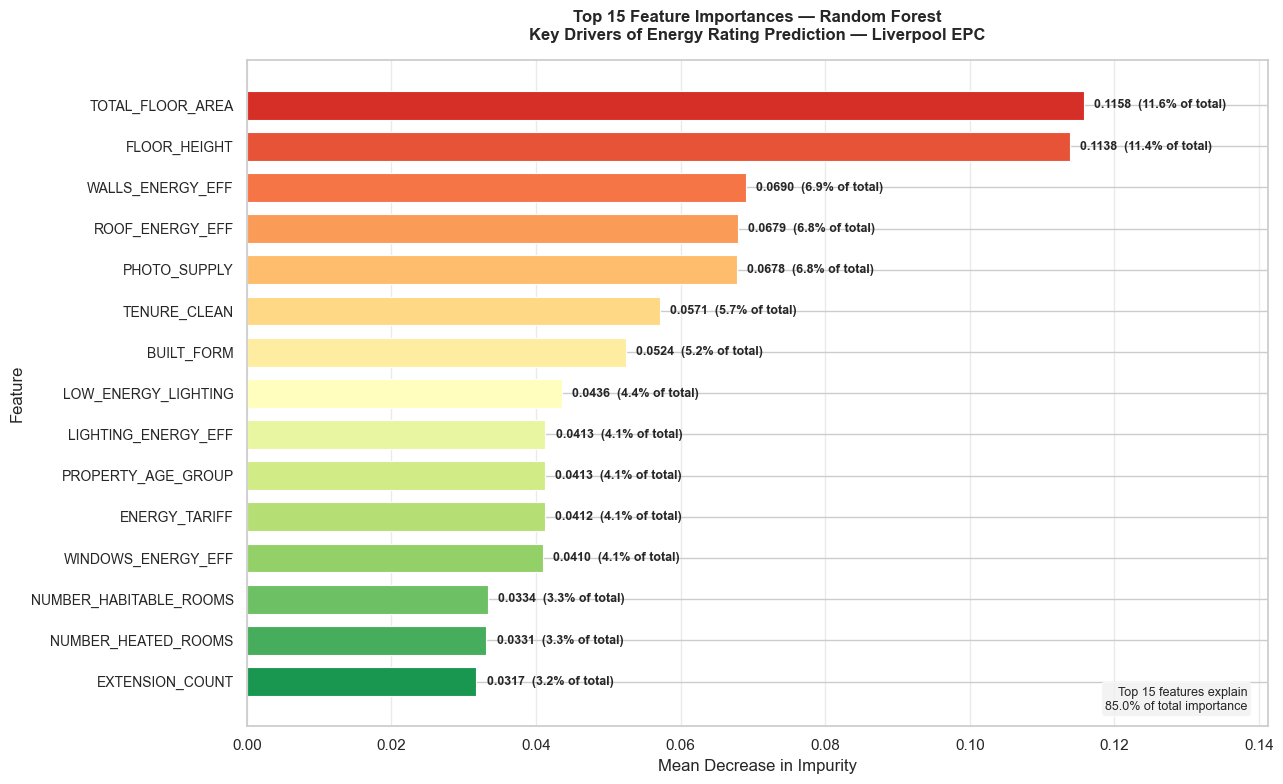

Top 10 features:


,Importance,% of Total
TOTAL_FLOOR_AREA,0.1158,11.6
FLOOR_HEIGHT,0.1138,11.4
WALLS_ENERGY_EFF,0.0690,6.9
ROOF_ENERGY_EFF,0.0679,6.8
PHOTO_SUPPLY,0.0678,6.8
TENURE_CLEAN,0.0571,5.7
BUILT_FORM,0.0524,5.2
LOW_ENERGY_LIGHTING,0.0436,4.4
LIGHTING_ENERGY_EFF,0.0413,4.1
PROPERTY_AGE_GROUP,0.0413,4.1


In [28]:
importances = rf_model.feature_importances_
fi_series   = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top15       = fi_series.head(15)
cumulative  = top15.cumsum() / fi_series.sum() * 100

fig, ax = plt.subplots(figsize=(13, 8))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(range(len(top15)), top15.values[::-1],
               color=colors_fi, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index[::-1], fontsize=10)
xlim = top15.max() * 1.22
ax.set_xlim(0, xlim)
for i, (bar, val) in enumerate(zip(bars, top15.values[::-1])):
    pct_total = val / fi_series.sum() * 100
    ax.text(val + xlim * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}  ({pct_total:.1f}% of total)',
            va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 15 Feature Importances — Random Forest\n'
             'Key Drivers of Energy Rating Prediction — Liverpool EPC', pad=15)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

top15_pct = (top15 / fi_series.sum() * 100).sum()
ax.text(0.98, 0.02, f'Top 15 features explain\n{top15_pct:.1f}% of total importance',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.savefig('chart12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features:')
top10 = pd.DataFrame({'Importance': fi_series.head(10).round(4),
                       '% of Total': (fi_series.head(10)/fi_series.sum()*100).round(1)})
display(top10)

### Chart 13: Feature Importance — All 25 Features (Ascending)

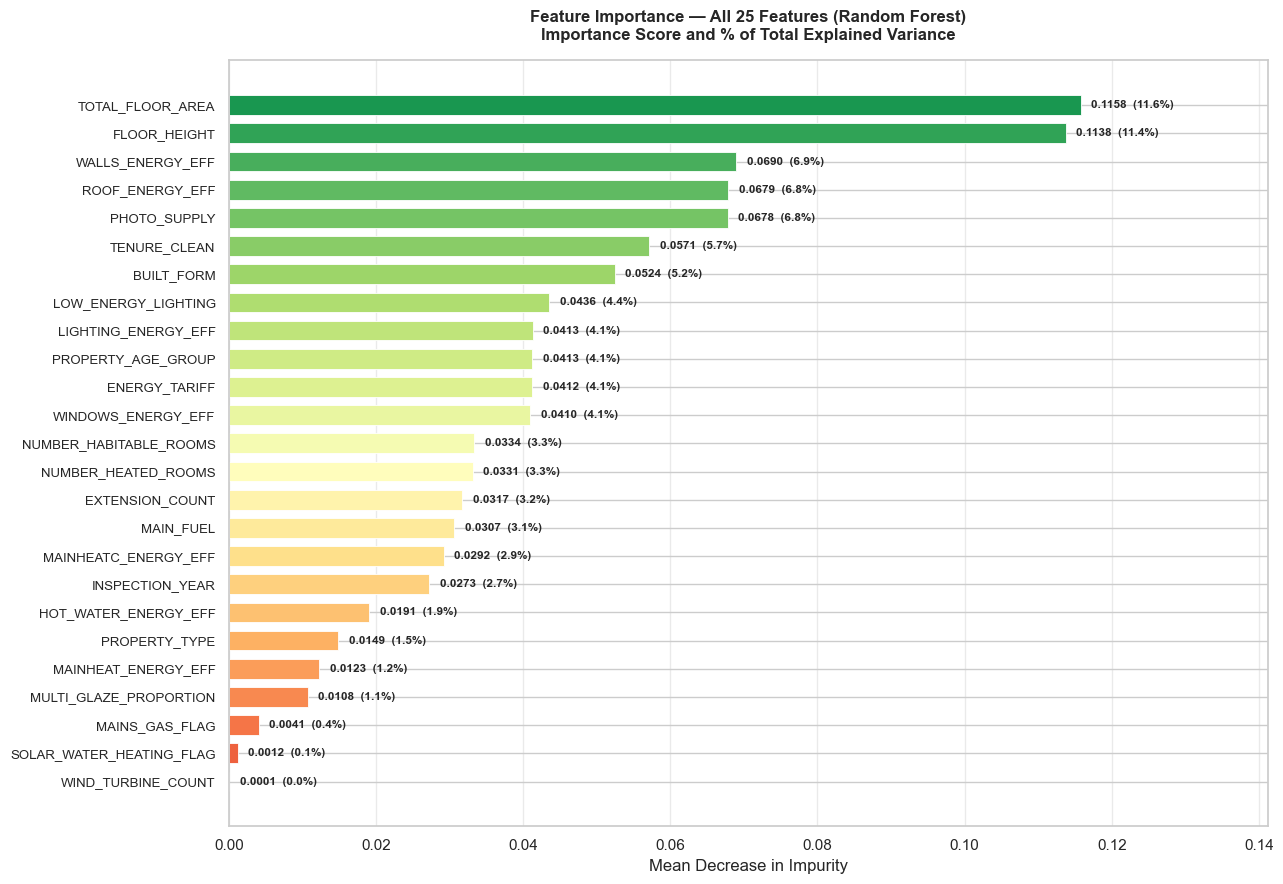

In [29]:
fi_asc = fi_series.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
colors_13 = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(fi_asc)))
bars13 = ax.barh(range(len(fi_asc)), fi_asc.values,
                  color=colors_13, edgecolor='white', linewidth=0.6, height=0.7)
ax.set_yticks(range(len(fi_asc)))
ax.set_yticklabels(fi_asc.index, fontsize=9.5)
xlim = fi_asc.max() * 1.22
ax.set_xlim(0, xlim)
for bar, val in zip(bars13, fi_asc.values):
    pct = val / fi_series.sum() * 100
    ax.text(val + xlim * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}  ({pct:.1f}%)', va='center', fontsize=8.5, fontweight='bold')
ax.set_title('Feature Importance — All 25 Features (Random Forest)\n'
             'Importance Score and % of Total Explained Variance', pad=15)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart13_feature_importance_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 14: Permutation Feature Importance

Calculating permutation importance...


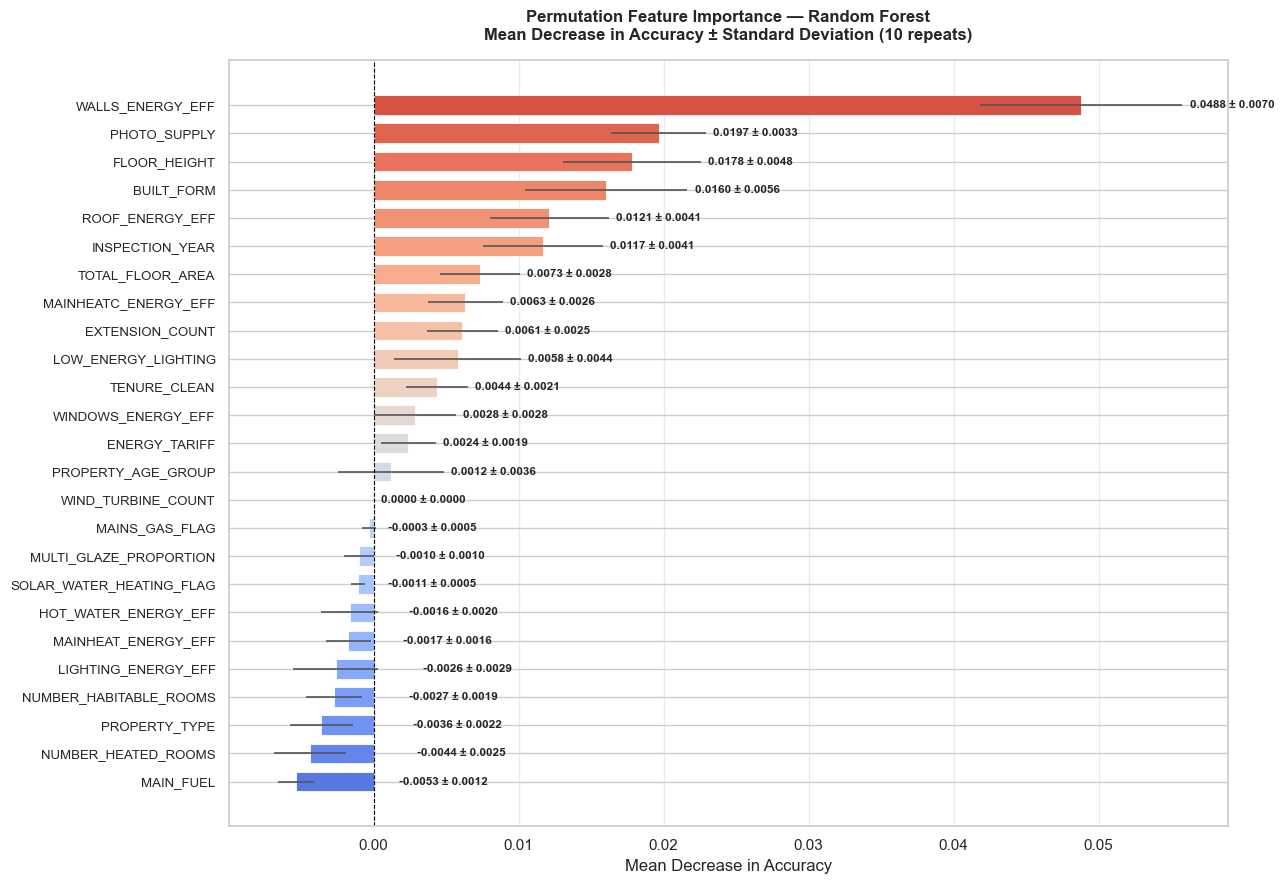


Permutation importance validates tree-based importances by directly
measuring accuracy drop when each feature is randomly shuffled.
Error bars show variability across 10 repeat shuffles.


In [30]:
print('Calculating permutation importance...')
perm       = permutation_importance(rf_model, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
perm_s     = pd.Series(perm.importances_mean, index=feature_cols).sort_values()
perm_std_s = pd.Series(perm.importances_std,  index=feature_cols).loc[perm_s.index]

fig, ax = plt.subplots(figsize=(13, 9))
colors_14 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(perm_s)))
bars14 = ax.barh(range(len(perm_s)), perm_s.values,
                  xerr=perm_std_s.values,
                  color=colors_14, edgecolor='white', linewidth=0.6,
                  height=0.7, error_kw={'elinewidth': 1.2, 'ecolor': '#555'})
ax.set_yticks(range(len(perm_s)))
ax.set_yticklabels(perm_s.index, fontsize=9.5)
for bar, val, std in zip(bars14, perm_s.values, perm_std_s.values):
    ax.text(max(val, 0) + max(std, 0) + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ± {std:.4f}',
            va='center', fontsize=8.5, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Feature Importance — Random Forest\n'
             'Mean Decrease in Accuracy ± Standard Deviation (10 repeats)', pad=15)
ax.set_xlabel('Mean Decrease in Accuracy')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart14_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Permutation importance validates tree-based importances by directly')
print('measuring accuracy drop when each feature is randomly shuffled.')
print('Error bars show variability across 10 repeat shuffles.')

## Section 8: Recommendations and Conclusion

### Key Findings

1. **68.6% of Liverpool properties are rated C**, reflecting a predominantly mid-range housing stock. Only 1.5% achieved A or B ratings, indicating significant room for city-wide improvement.

2. **Construction age is the primary structural driver**: Pre-1900 properties average 69.5 efficiency vs 78.6 for Post-2021 builds — a 9.1-point gap driven by successive improvements in UK building regulations.

3. **Wall insulation has the greatest single-feature impact**: upgrading from Very Poor to Very Good adds 12 efficiency points. Roof insulation shows a 10.8-point range. These physical retrofits represent the most cost-effective intervention pathway.

4. **The predictive model (Gradient Boosting) achieves 81.2% accuracy** using only observable building characteristics — without any SAP-derived metrics. The 5-fold CV score confirms the model generalises well beyond the training data.

5. **The mean annual cost saving potential is £128.50 per property**, representing approximately £588,500 per year across all 4,579 properties if improvements were made.

### Recommendations

1. **Target pre-1950 housing stock first**: 2,234 properties (48.8%) were built before 1950 and show the lowest average efficiency. Cavity wall and loft insulation programmes should prioritise this stock.

2. **Address the owner-occupied gap**: Owner-occupied properties show the largest efficiency gap (8.9 points) — the greatest unrealised potential of any tenure group. Financial incentives or green mortgages could drive uptake.

3. **Expand ECO scheme access for private renters**: Private rented stock shows a 7.8-point efficiency gap. Expanding eligibility criteria would benefit tenants who cannot fund improvements themselves.

4. **Use the predictive model for pre-assessment targeting**: At 81.2% accuracy from building records alone, the model can flag low-performing properties before costly physical assessments, enabling smarter resource allocation.

5. **Explore community heat networks**: Liverpool's dense concentration of pre-1950 terraced housing makes it suitable for district heating, which can deliver CO2 reductions across multiple properties simultaneously.

In [31]:
print('Notebook complete. Summary:')
print()
summary_final = pd.DataFrame({
    'Item': [
        'Properties analysed', 'Features after wrangling',
        'Predictive features (no leakage)', 'Charts generated',
        'Logistic Regression accuracy', 'Random Forest accuracy',
        'Gradient Boosting accuracy', 'Best model CV score (5-fold)',
        'Mean annual cost saving', 'Cleaned dataset'
    ],
    'Value': [
        f'{len(df):,}', df.shape[1], len(feature_cols), 15,
        f'{lr_acc:.4f}', f'{rf_acc:.4f}', f'{gb_acc:.4f}',
        f'{cv_gb.mean():.4f} (Gradient Boosting)',
        f'£{df["COST_SAVING_POTENTIAL"].mean():.2f}/property/year',
        'liverpool_epc_cleaned.csv'
    ]
})
display(summary_final)

Notebook complete. Summary:



,Item,Value
0,Properties analysed,"4,579"
1,Features after wrangling,72
2,Predictive features (no leakage),25
3,Charts generated,15
4,Logistic Regression accuracy,0.7653
5,Random Forest accuracy,0.8079
6,Gradient Boosting accuracy,0.8122
7,Best model CV score (5-fold),0.8346 (Gradient Boosting)
8,Mean annual cost saving,£128.51/property/year
9,Cleaned dataset,liverpool_epc_cleaned.csv
